In [1]:
from SCFT_functions import *
from DNA_input import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from numba import njit, prange
from matplotlib.colors import LogNorm

Using cupy


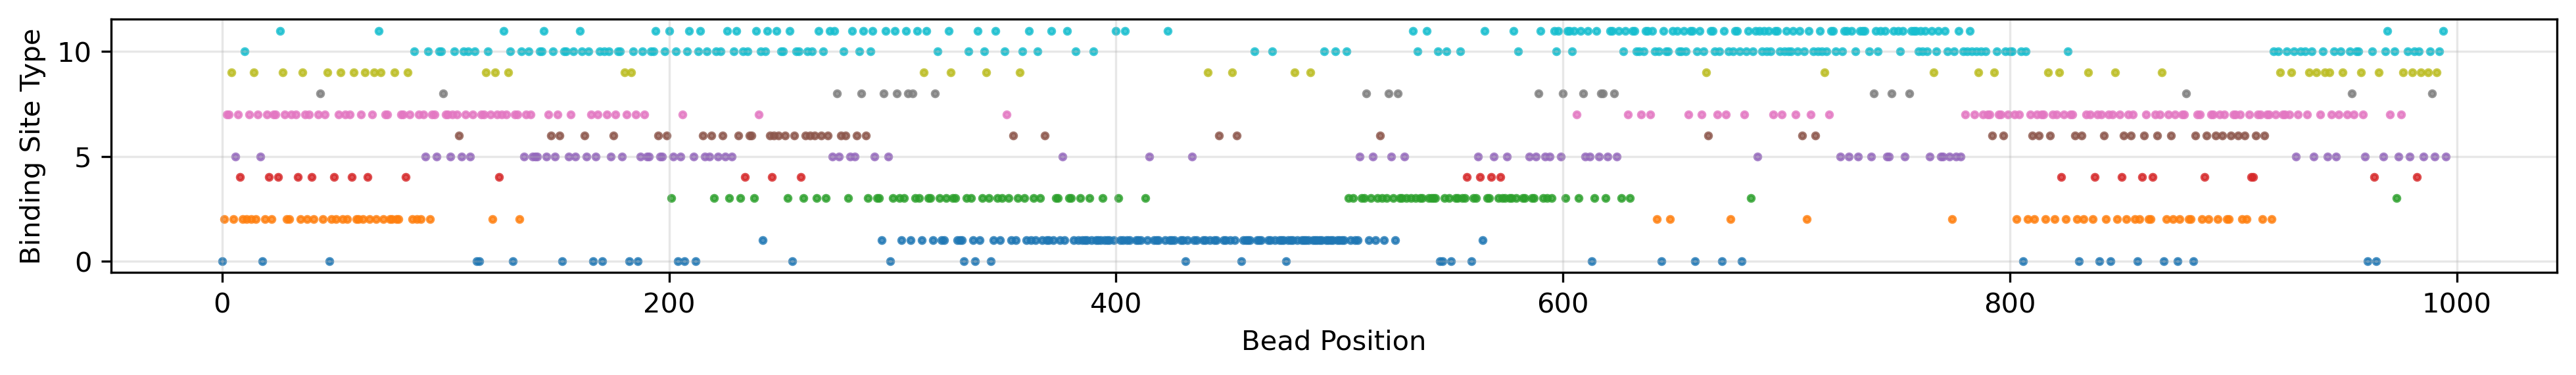

[0.11044177 0.06927711 0.09538153 0.02710843 0.08333333 0.05722892
 0.13554217 0.02409639 0.04919679 0.15160643 0.10742972 0.08935743]


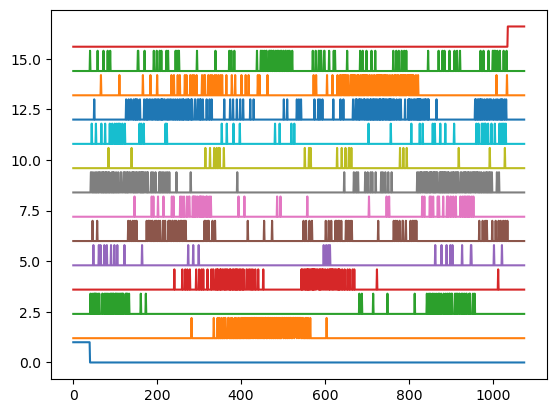

[1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1.]
(12,)
[0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0.]
1075


In [2]:
infered_sequence = np.load("../Bead_sequence_MC/IMR90_infer_sequence_30_42.npy")
visualize_config(infered_sequence, np.max(infered_sequence))
chain_interaction_binary = colors_to_onehot(infered_sequence)
#ns = chain_interaction_binary.shape[1]-1
plt.show()

print(np.mean(chain_interaction_binary, axis = 1))
extra_length = 40
chain_interaction_binary_temp = np.zeros((chain_interaction_binary.shape[0]+2,chain_interaction_binary.shape[1]+2*extra_length))
chain_interaction_binary_temp[1:-1,extra_length:-extra_length] = chain_interaction_binary
chain_interaction_binary_temp[0, 0:extra_length] = 1
chain_interaction_binary_temp[-1, -extra_length:] = 1

ns = chain_interaction_binary_temp.shape[1]-1

for i in range(chain_interaction_binary_temp.shape[0]):
    plt.plot(chain_interaction_binary_temp[i]+i*1.2)
plt.show()

AB_binding_class_epigenetics = np.load("AB_binding_class_epigenetics.npy")
print(AB_binding_class_epigenetics)
print(AB_binding_class_epigenetics.shape)

AB_binding_class_epigenetics_temp = np.zeros(AB_binding_class_epigenetics.shape[0]+2)
AB_binding_class_epigenetics_temp[1:-1] = AB_binding_class_epigenetics
print(AB_binding_class_epigenetics_temp)

print(ns)

In [3]:
from joblib import Parallel, delayed
from itertools import product

def single_run(chi_offset):
    PP = 475
    PS = 350

    chi_pp = PP*xp.ones((AB_binding_class_epigenetics_temp.shape[0],AB_binding_class_epigenetics_temp.shape[0]))
    chi_ps = PS*xp.ones(AB_binding_class_epigenetics_temp.shape[0])

    for i in range(AB_binding_class_epigenetics_temp.shape[0]):
        if AB_binding_class_epigenetics_temp[i]==0: # B
            chi_ps[i] = PS+chi_offset
        else: # A
            chi_ps[i] = PS-chi_offset
        for j in range(AB_binding_class_epigenetics_temp.shape[0]):
            if (AB_binding_class_epigenetics_temp[i]==0) ^ (AB_binding_class_epigenetics_temp[j]==0):
                chi_pp[i, j] = PP+chi_offset
            elif AB_binding_class_epigenetics_temp[i]==1 and AB_binding_class_epigenetics_temp[j]==1:
                chi_pp[i, j] = PP-chi_offset

    end_interaction_strength_ps = PS+50
    end_interaction_strength_pp = PP+50

    chi_ps[0] = end_interaction_strength_ps
    chi_ps[-1] = end_interaction_strength_ps

    chi_pp[0, :] = end_interaction_strength_pp
    chi_pp[-1, :] = end_interaction_strength_pp
    chi_pp[:, 0] = end_interaction_strength_pp
    chi_pp[:, -1] = end_interaction_strength_pp

    print(chi_pp)
    print(chi_ps)

    N = 200
    Nseg = 1

    nx = ny = 128
    initial_qsr = xp.ones((nx, ny))
    L = 30 #dimension of the box

    ns = chain_interaction_binary_temp.shape[1]-1

    boundary = xp.random.rand(nx,ny)

    polymer = Scft(
        N = N,
        Lx=L, Ly=L,
        phibar=0.15, # volume fraction of polymer
        l_p=xp.sqrt(N),
        n_seg=Nseg, # contour length of polymer normalized from 0-1
        nx=nx, ny=ny,
        ns=ns,
        iterations=8000,
        error_tol=1e-12,
        chain_interaction=xp.asarray(chain_interaction_binary_temp),
        self_avoiding=0,
        initial_qsr=xp.array(boundary),
        mixing_rate=0.01,
        chi_polymer_block = chi_pp,
        chi_polymer_s = chi_ps,
        PB = 1,
        close_boundary=True,
    )

    wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist = initialization(polymer, seed = 5, shift = 0)
    wsr, phi, phi_blocks, qsr, qsr_d, diff, free_energy_hist = scft_loop(polymer, wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist, polymer_loop=True)

    corr_2d = pair_correlation_2D(to_numpy(qsr*qsr_d))

    return to_numpy(phi_blocks), to_numpy(qsr), diff, corr_2d, free_energy_hist

def parameter_sweep_2d(n_jobs=3, backend="loky", seed=5):
    offsets = np.array([-30,-25,-20,-10,-5,0,5,10,15,20,25,30])

    results = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(single_run)(chi_offset) for (chi_offset) in
        tqdm(offsets, total = len(offsets))
    )
    phi_list, qsr_list, diff_list, corr_2d_list, free_energy_hist = zip(*results)

    return phi_list, qsr_list, diff_list, corr_2d_list, free_energy_hist


In [4]:
offsets = np.array([-30,-25,-20,-10,-5,0,5,10,15,20,25,30])
phi_list, qsr_list, diff_list, corr_2d_list, free_energy_hist = parameter_sweep_2d()

np.savez("AB_offset_PS", phi_list = phi_list, qsr_list = qsr_list, diff_list = diff_list, corr_2d_list = corr_2d_list, free_energy_hist = free_energy_hist)

  0%|          | 0/12 [00:00<?, ?it/s]

In [5]:
phi_blocks_grid = np.array(phi_list)
print(phi_blocks_grid.shape)
print(phi_blocks_grid[0,0].shape)

diff_grid = np.array(diff_list)
print(diff_grid.shape)

(12, 14, 128, 128)
(128, 128)
(12, 8000)


-20


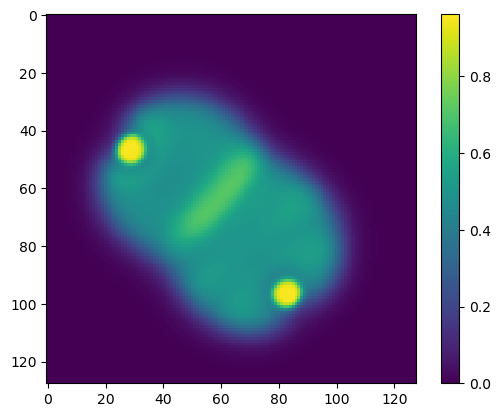

In [6]:
idx = 2
print(offsets[idx])
phi = np.sum(phi_blocks_grid[idx], axis=0)
plt.imshow(phi, cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

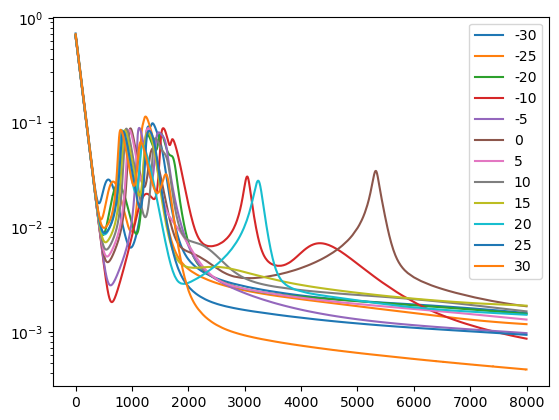

In [7]:

for i in range(phi_blocks_grid.shape[0]):
    plt.plot(diff_grid[i,:], label=str(offsets[i]))
plt.legend()
plt.yscale("log")

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def _threshold_by_mass_fraction(field2d, mass_fraction=0.1):
    flat = field2d.ravel()
    if flat.size == 0:
        return np.inf
    total = flat.sum()
    if total <= 0:
        return np.inf

    order = np.argsort(flat)[::-1]  # descending
    sorted_vals = flat[order]
    cumsum = np.cumsum(sorted_vals)

    target = mass_fraction * total
    idx = np.searchsorted(cumsum, target, side="left")
    idx = min(idx, len(sorted_vals) - 1)
    return sorted_vals[idx]


def plot_phi_blocks_dense_small_on_top(
    phi_blocks,
    dx=1.0, dy=1.0,
    Lx=None, Ly=None,
    labels=None,
    mode="fraction_of_mass",
    mass_fraction=0.1,
    percentile=95,
    relative_to_max=0.9,
    min_abs=None,
    transpose=True,
    ax=None,
    title="Dense component regions (small on top)",
):
    """
    Visualize dense regions of each component in phi_blocks with non-overlapping colors.

    Non-overlap rule:
        Each pixel is finally assigned to at most one component, but if multiple
        components are 'dense' there, the component whose dense area is smaller
        (global) wins (is drawn on top).

    Parameters
    ----------
    phi_blocks : ndarray, shape (n_comp, nx, ny)
        Component densities.
    mode : str
        How to define "dense" per component:
        - "fraction_of_mass": keep top pixels that contain given fraction of component mass.
        - "percentile": keep pixels above given percentile within each component.
        - "relative_to_max": keep pixels >= relative_to_max * max(component).
        - "argmax_only": ignore thresholds and just use argmax segmentation.
    min_abs : float or None
        Optional absolute floor to suppress noise (applied after the above mode).
    """

    phi_blocks = np.asarray(phi_blocks)
    n_comp, nx, ny = phi_blocks.shape

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    dense_masks = []

    if mode == "argmax_only":
        # classic winner-take-all, no small-on-top logic needed, but we still keep iface similar
        winner = np.argmax(phi_blocks, axis=0)
        for m in range(n_comp):
            mask = (winner == m)
            if min_abs is not None:
                mask &= (phi_blocks[m] >= min_abs)
            dense_masks.append(mask)
    else:
        # Threshold each component independently
        for m in range(n_comp):
            field = phi_blocks[m]

            if mode == "fraction_of_mass":
                thr = _threshold_by_mass_fraction(field, mass_fraction=mass_fraction)
                mask = field >= thr
            elif mode == "percentile":
                thr = np.percentile(field, percentile)
                mask = field >= thr
            elif mode == "relative_to_max":
                mx = field.max() if field.size else 0.0
                thr = relative_to_max * mx
                mask = field >= thr
            else:
                raise ValueError(f"Unknown mode: {mode}")

            if min_abs is not None:
                mask &= (field >= min_abs)

            dense_masks.append(mask)

    # Compute global dense area per component
    areas = np.array([mask.sum() for mask in dense_masks])

    # Order components from largest dense area to smallest
    # so that small components are drawn LAST and override larger ones.
    order = np.argsort(areas)[::-1]  # indices, largest -> smallest

    # Create label image, -1 is background
    label_img = -1 * np.ones((nx, ny), dtype=int)

    for m in order:
        mask = dense_masks[m]
        # small regions (processed last) will overwrite overlapping pixels
        label_img[mask] = m

    # Build colormap
    base = plt.get_cmap("tab10")
    colors = [base(i) for i in range(min(n_comp, 10))]
    if n_comp > 10:
        base2 = plt.get_cmap("tab20")
        colors += [base2(i) for i in range(n_comp - 10)]
    cmap = ListedColormap(colors[:n_comp])
    cmap.set_bad(alpha=0.0)

    # Mask background
    masked = np.ma.masked_where(label_img < 0, label_img)

    # Extent for physical coordinates
    if Lx is not None and Ly is not None:
        extent = [0, Lx, 0, Ly]
    else:
        extent = None

    to_plot = masked.T if transpose else masked
    ax.imshow(
        to_plot,
        origin="lower",
        cmap=cmap,
        interpolation="nearest",
        extent=extent,
    )

    # Legend
    if labels is None:
        labels = [f"comp {i}" for i in range(n_comp)]

    handles = [
        mpatches.Patch(color=colors[i], label=labels[i])
        for i in range(n_comp)
    ]
    #ax.legend(handles=handles, loc="upper right", frameon=True)

    ax.set_title(title)
    ax.set_xlabel("x" if extent else "ix")
    ax.set_ylabel("y" if extent else "iy")

    return ax


-30


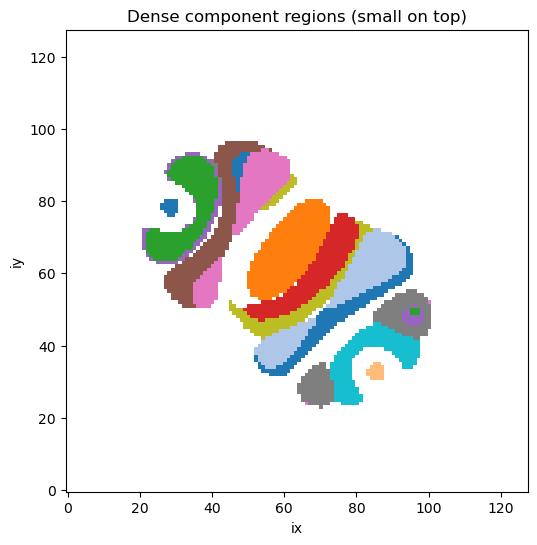

-25


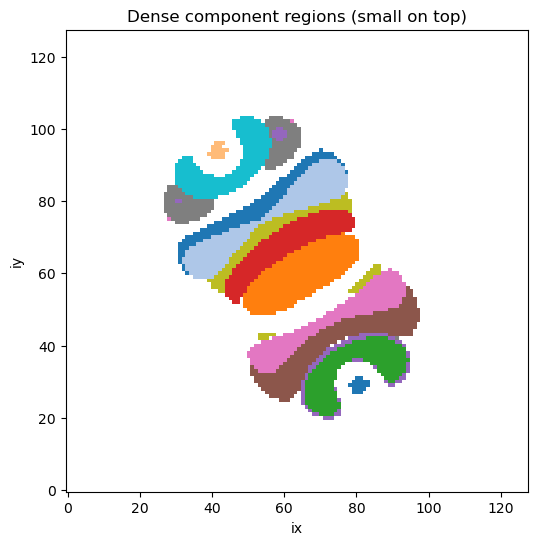

-20


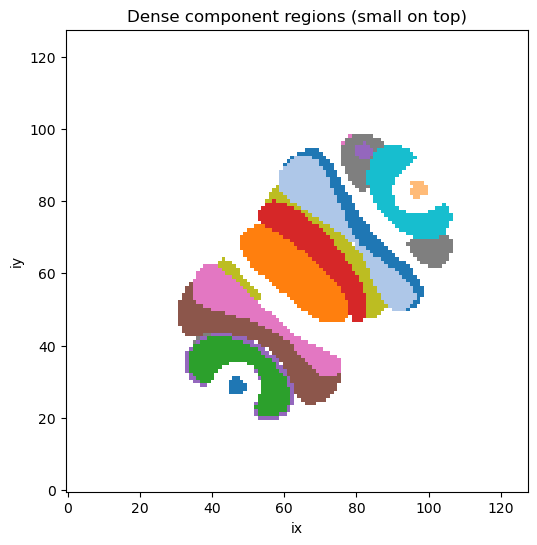

-10


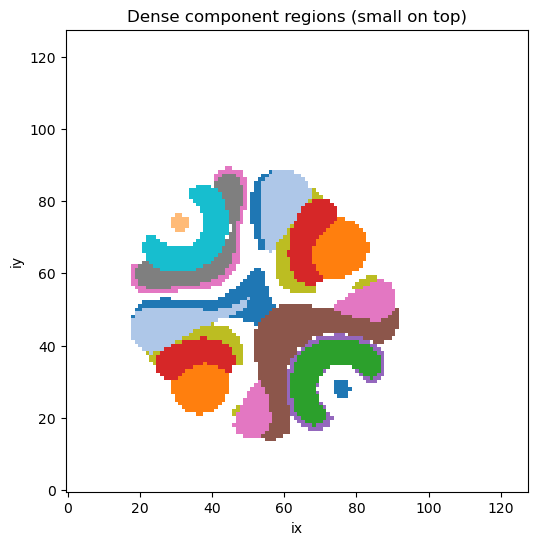

-5


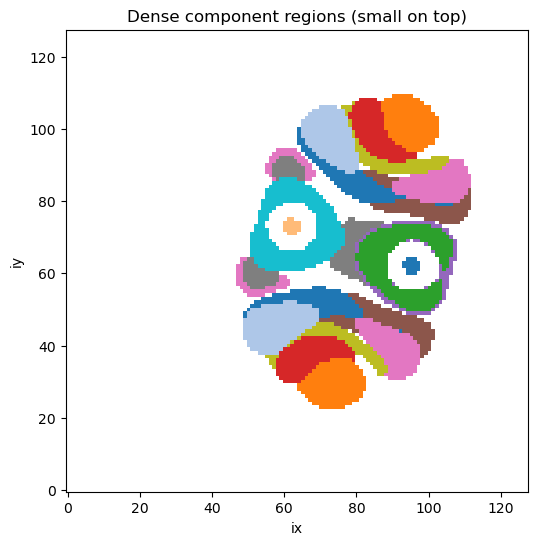

0


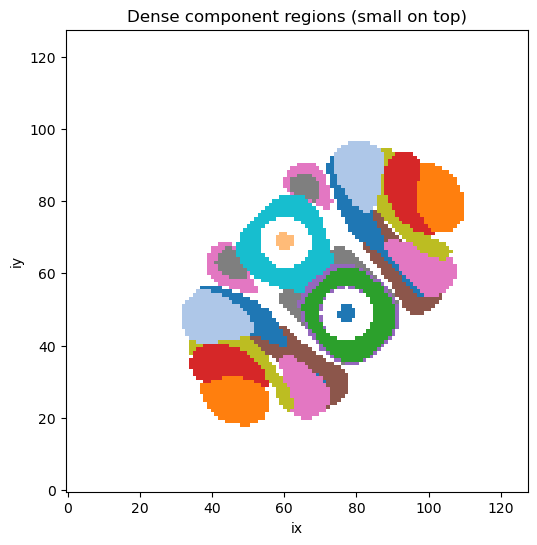

5


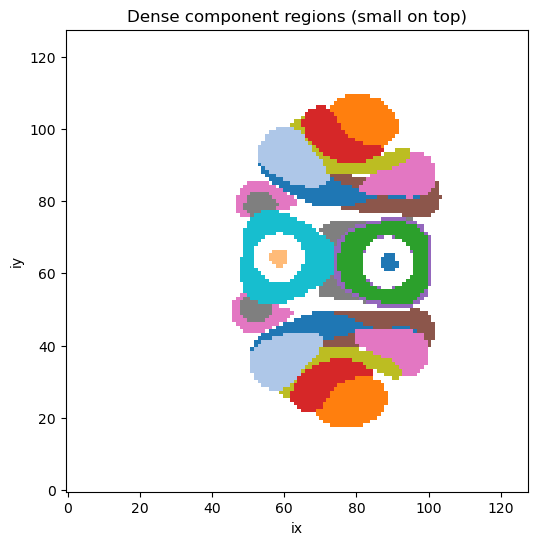

10


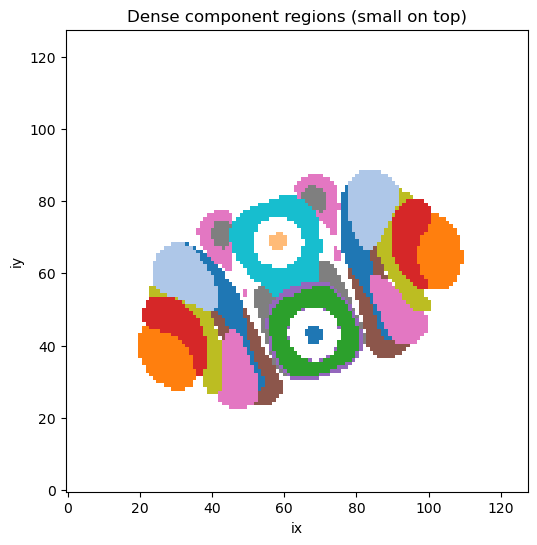

15


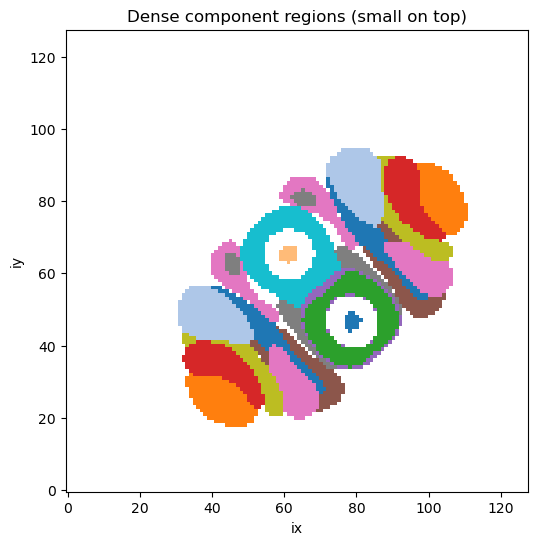

20


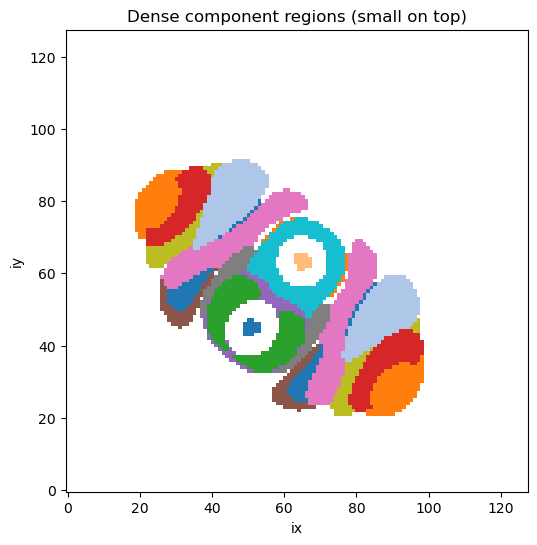

25


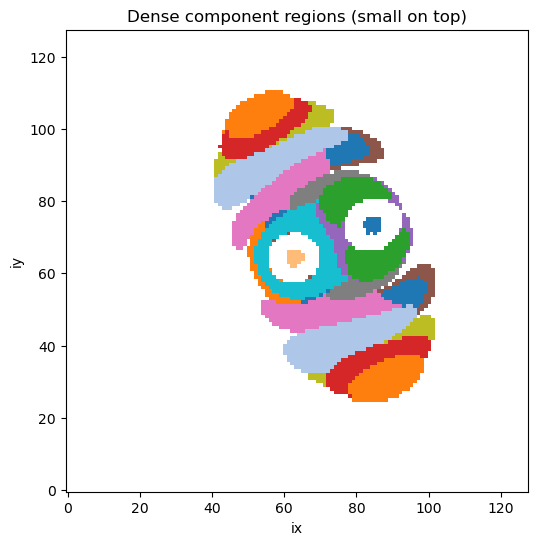

30


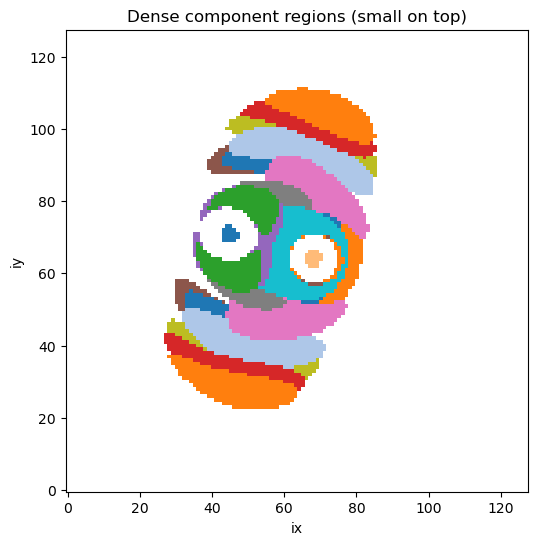

In [16]:
for i in range(phi_blocks_grid.shape[0]):
    print(offsets[i])
    #plot_phi_blocks_periodic(phi_blocks_grid[i], extent=(0, 56, 0, 56), percentile=90, shift_x=0, shift_y=0)
    plot_phi_blocks_dense_small_on_top(
    phi_blocks_grid[i],
    mode="fraction_of_mass",   # good default for "most dense areas"
    mass_fraction=0.2,         # top 10% of each component mass
    min_abs=1e-6,              # optional noise floor
    )
    plt.show()

-30


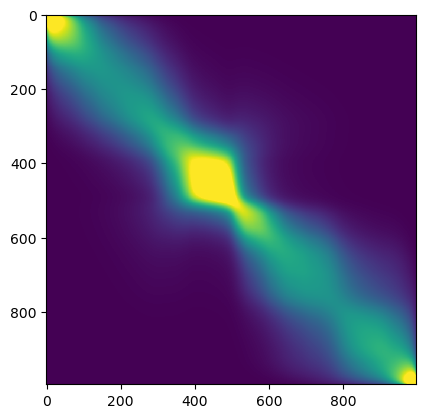

-25


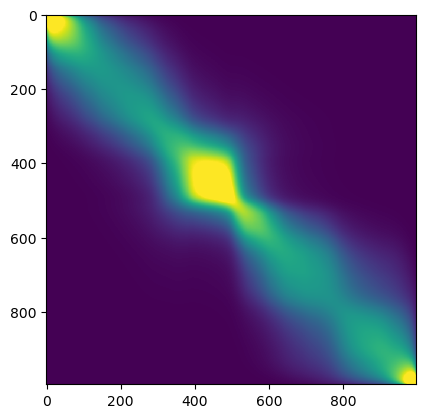

-20


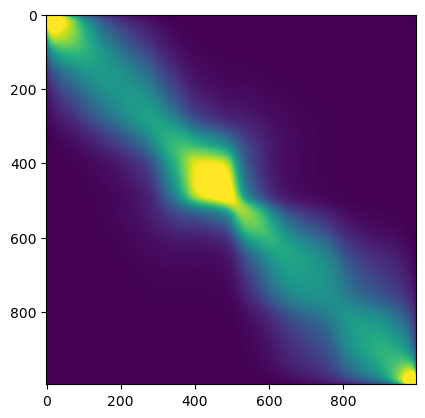

-10


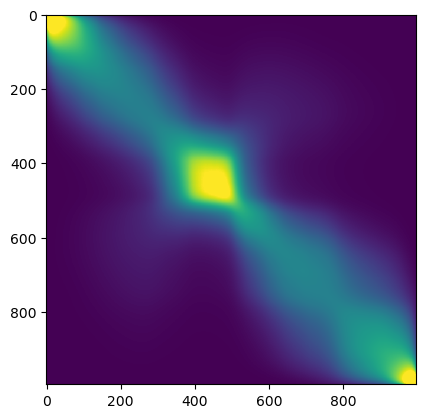

-5


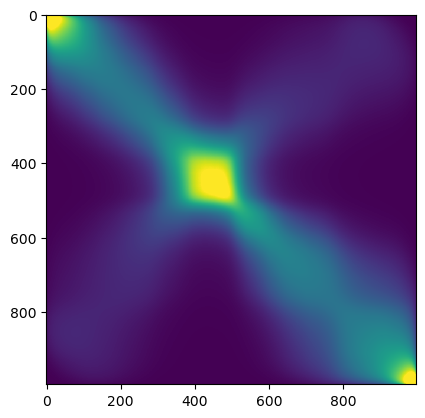

0


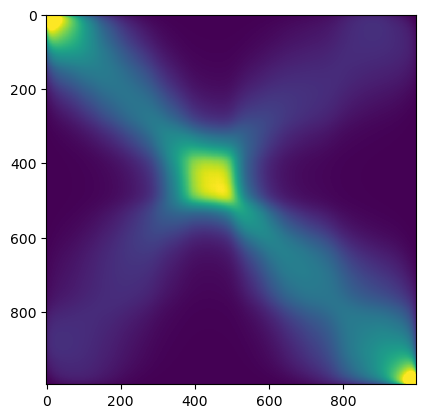

5


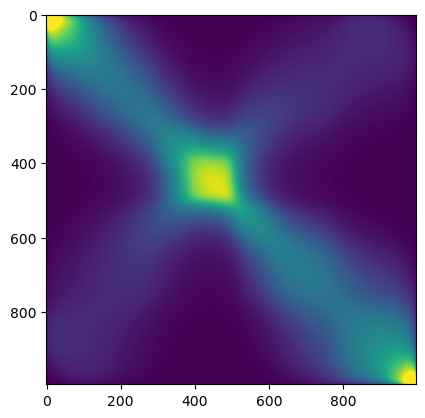

10


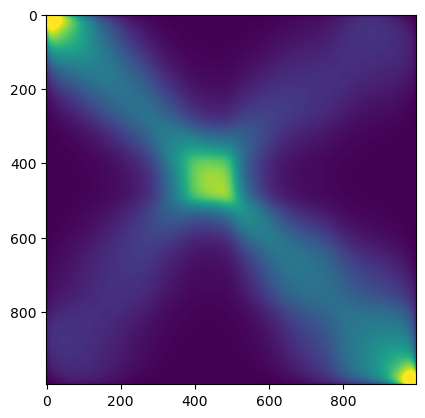

15


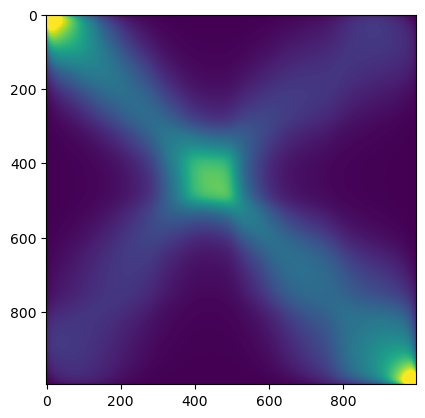

20


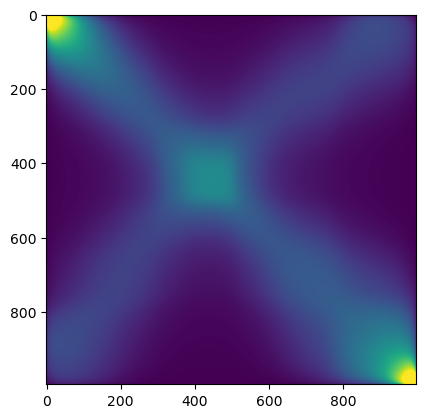

25


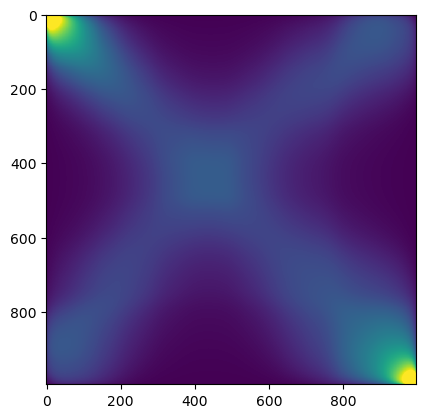

30


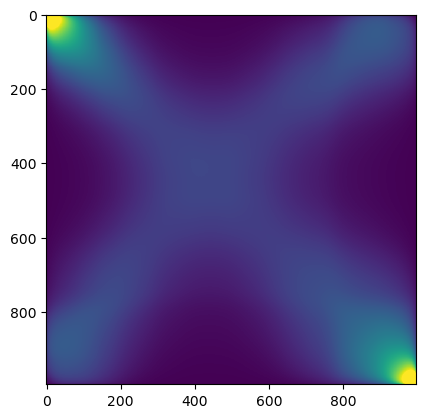

In [12]:
crop_length = extra_length
for i in range(phi_blocks_grid.shape[0]):
    print(offsets[i])
    corr2d = corr_2d_list[i]
    dynamic_range = 2.5 * np.std(corr2d)
    try:
        plt.imshow(corr2d[crop_length:-crop_length, crop_length:-crop_length], cmap='viridis', interpolation='nearest', aspect=1,
               #vmin=-dynamic_range,
               vmax=+dynamic_range,
                   #norm=LogNorm()
               )
        plt.show()
    except:
        print("warning")

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def _threshold_by_mass_fraction(field2d, mass_fraction=0.1):
    """
    Return a threshold value such that keeping pixels >= threshold
    captures approximately `mass_fraction` of the total mass.
    """
    flat = field2d.ravel()
    if flat.size == 0:
        return np.inf
    total = flat.sum()
    if total <= 0:
        return np.inf

    order = np.argsort(flat)[::-1]  # descending
    sorted_vals = flat[order]
    cumsum = np.cumsum(sorted_vals)

    target = mass_fraction * total
    idx = np.searchsorted(cumsum, target, side="left")
    idx = min(idx, len(sorted_vals) - 1)
    return sorted_vals[idx]


def plot_phi_blocks_overlapping_by_property(
    phi_blocks,
    prop_flags,
    background=None,
    Lx=None,
    Ly=None,
    mode="fraction_of_mass",
    mass_fraction=0.1,
    percentile=95,
    relative_to_max=0.9,
    min_abs=None,
    transpose=True,
    ax=None,
    alpha_fill=0.4,
    background_cmap="Greys",
    background_vmin=None,
    background_vmax=None,
    title="Overlapping dense component regions by property",
    draw_contours=True,
):
    """
    Plot overlapping dense regions of each component in `phi_blocks`:

      - Each component's dense pixels are chosen by `mode`.
      - Components are colored by `prop_flags` (0/1 -> yellow/blue).
      - Layers overlap with transparency (no segmentation).
      - Optional background (e.g., total density) plotted underneath.
      - Optional thin black contours mark each component's blobs.

    Parameters
    ----------
    phi_blocks : ndarray, shape (n_comp, nx, ny)
        2D density of each component.
    prop_flags : array-like, shape (n_comp,)
        0/1 property for each component:
          1 -> blue, 0 -> yellow.
    background : ndarray or None, shape (nx, ny), optional
        Background scalar field to plot underneath (e.g. total phi).
        If None, only blobs are plotted.
    Lx, Ly : float or None
        Physical system size in x and y. If provided, used as extent.
    mode : {"fraction_of_mass", "percentile", "relative_to_max", "argmax_only"}
        How to define "dense" pixels per component:
          - "fraction_of_mass": keep top mass_fraction of total integral.
          - "percentile": keep pixels above given percentile.
          - "relative_to_max": keep pixels >= relative_to_max * max.
          - "argmax_only": ignore thresholds; each pixel assigned to argmax.
    mass_fraction : float
        Used if mode == "fraction_of_mass".
    percentile : float
        Used if mode == "percentile".
    relative_to_max : float
        Used if mode == "relative_to_max".
    min_abs : float or None
        Optional absolute floor: pixels < min_abs are never dense.
    transpose : bool
        If True, transpose arrays when plotting so axes match (x,y).
    ax : matplotlib.axes.Axes or None
        Axes to plot on. If None, a new figure/axes are created.
    alpha_fill : float
        Transparency for blob fills (0=transparent, 1=opaque).
    background_cmap : str
        Colormap for background field.
    background_vmin, background_vmax : float or None
        Color limits for background imshow.
    title : str
        Axes title.
    draw_contours : bool
        If True, draw thin black contours for each component's dense region.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the plot.
    """

    phi_blocks = np.asarray(phi_blocks)
    n_comp, nx, ny = phi_blocks.shape

    prop_flags = np.asarray(prop_flags).astype(int)
    if prop_flags.shape[0] != n_comp:
        raise ValueError("prop_flags must have length n_comp (first dimension of phi_blocks).")

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    # Coordinate extent
    if Lx is not None and Ly is not None:
        extent = [0, Lx, 0, Ly]
    else:
        extent = None

    # 1) Plot background, if given
    if background is not None:
        background = np.asarray(background)
        if background.shape != (nx, ny):
            raise ValueError("background must have shape (nx, ny) consistent with phi_blocks.")

        bg_to_plot = background.T if transpose else background
        im = ax.imshow(
            bg_to_plot,
            origin="lower",
            extent=extent,
            cmap=background_cmap,
            vmin=background_vmin,
            vmax=background_vmax,
        )
        # optional: comment out if you don't want a colorbar here
        fig.colorbar(im, ax=ax, label="background")

    # 2) Build dense masks per component (no winner-take-all)
    dense_masks = []

    if mode == "argmax_only":
        winner = np.argmax(phi_blocks, axis=0)
        for m in range(n_comp):
            mask = (winner == m)
            if min_abs is not None:
                mask &= (phi_blocks[m] >= min_abs)
            dense_masks.append(mask)
    else:
        for m in range(n_comp):
            field = phi_blocks[m]

            if mode == "fraction_of_mass":
                thr = _threshold_by_mass_fraction(field, mass_fraction=mass_fraction)
                mask = field >= thr
            elif mode == "percentile":
                thr = np.percentile(field, percentile)
                mask = field >= thr
            elif mode == "relative_to_max":
                mx = field.max() if field.size else 0.0
                thr = relative_to_max * mx
                mask = field >= thr
            else:
                raise ValueError(f"Unknown mode: {mode}")

            if min_abs is not None:
                mask &= (field >= min_abs)

            dense_masks.append(mask)

    # 3) Overlapping RGBA layers
    alpha_fill = float(alpha_fill)
    alpha_fill = max(0.0, min(1.0, alpha_fill))

    blue_rgba   = np.array([0.2, 0.4, 0.9, alpha_fill])
    yellow_rgba = np.array([0.95, 0.85, 0.2, alpha_fill])

    for m in range(n_comp):
        mask = dense_masks[m]
        if not np.any(mask):
            continue

        rgba = blue_rgba if prop_flags[m] == 1 else yellow_rgba

        overlay = np.zeros((nx, ny, 4), dtype=float)
        overlay[mask] = rgba

        overlay_to_plot = overlay.transpose(1, 0, 2) if transpose else overlay

        ax.imshow(
            overlay_to_plot,
            origin="lower",
            interpolation="nearest",
            extent=extent,
        )

        # Optional black contour per component
        if draw_contours:
            mask_plot = mask.T if transpose else mask
            ax.contour(
                mask_plot,
                levels=[0.5],
                colors="k",
                linewidths=0.5,
                origin="lower",
                extent=extent,
            )

    # 4) Legend: only two colors, one per property value
    handles = [
        mpatches.Patch(color=blue_rgba,   label="A Compartment"),
        mpatches.Patch(color=yellow_rgba, label="B Compartment"),
    ]
    ax.legend(handles=handles, loc="upper right", frameon=True)

    #ax.set_title(title)
    ax.set_xlabel("x" if extent else "ix")
    ax.set_ylabel("y" if extent else "iy")

    return ax


-30


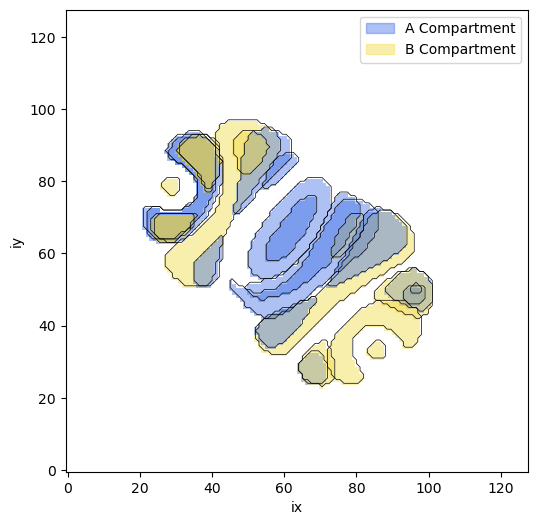

-25


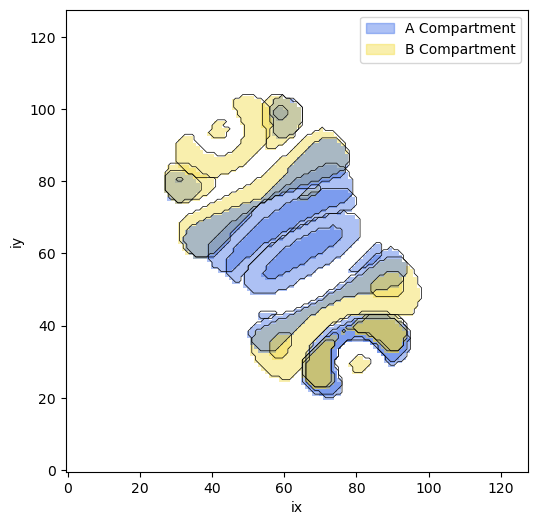

-20


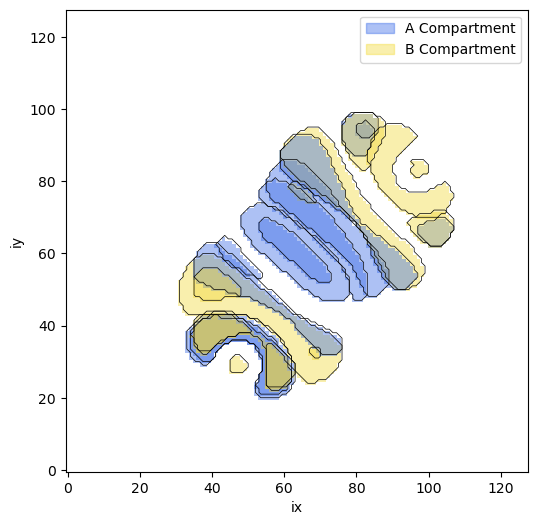

-10


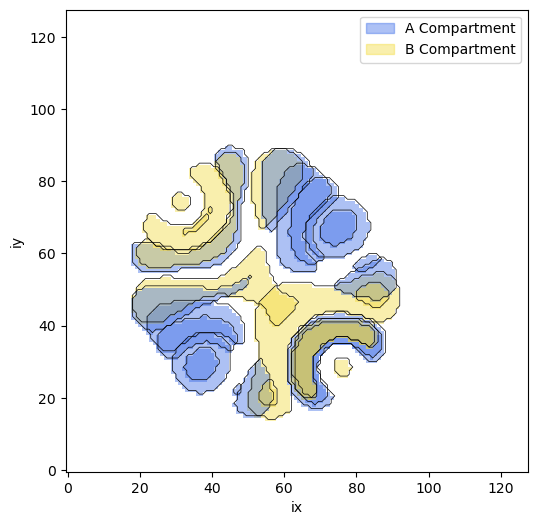

-5


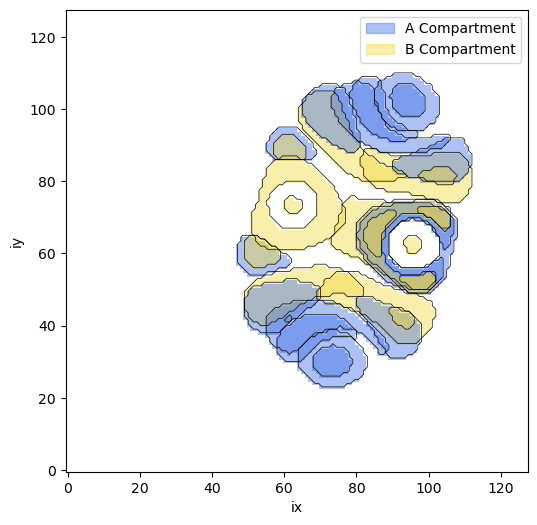

0


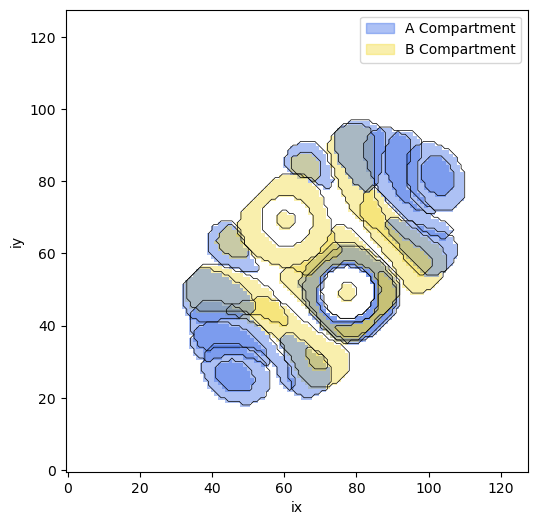

5


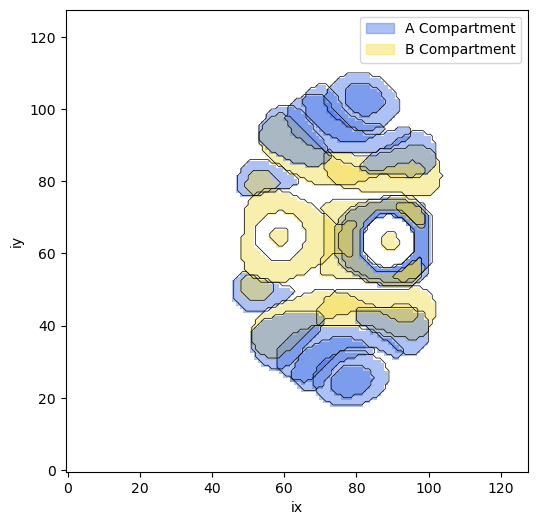

10


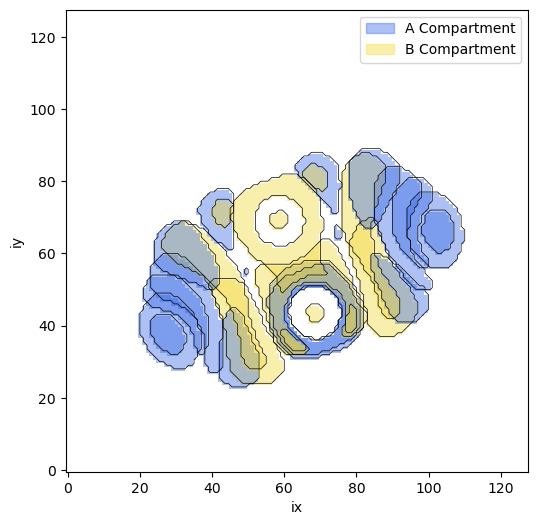

15


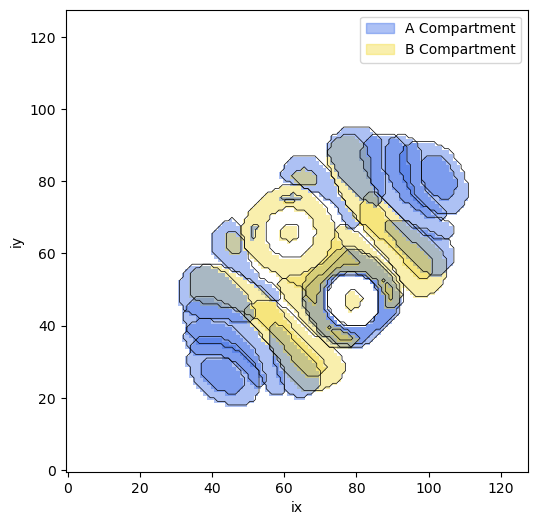

20


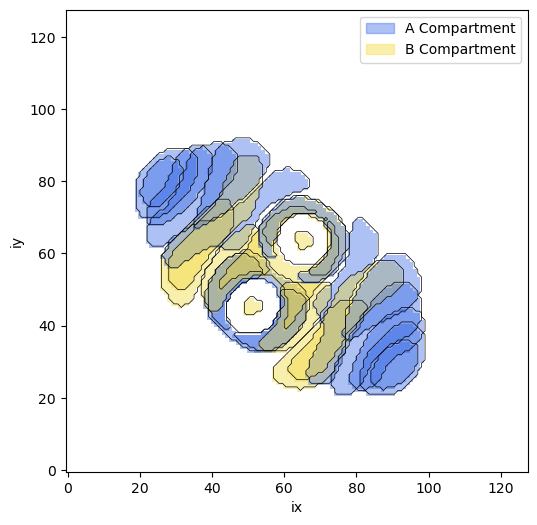

25


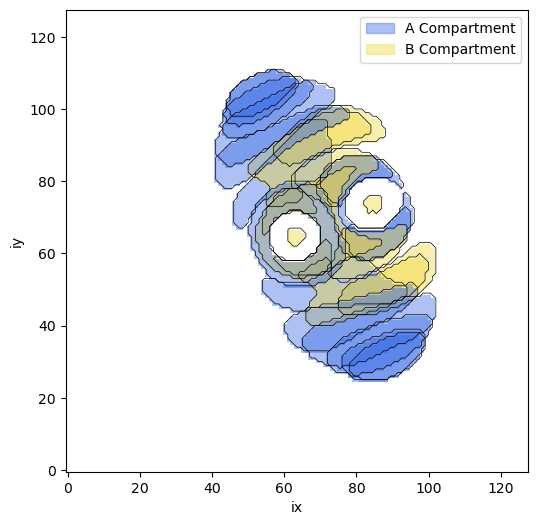

30


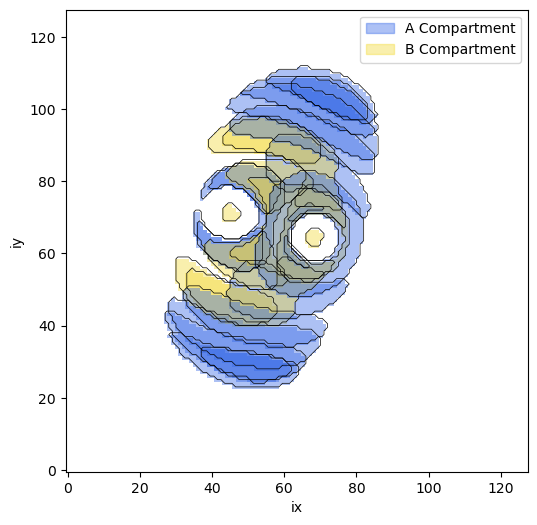

In [30]:
for i in range(phi_blocks_grid.shape[0]):
    print(offsets[i])

    fig, ax = plt.subplots(figsize=(6, 6))

    plot_phi_blocks_overlapping_by_property(
        phi_blocks_grid[i],
        prop_flags=AB_binding_class_epigenetics_temp,
        #background=self.phi,     # e.g. total density as background
        mode="fraction_of_mass", # or "percentile", "relative_to_max", "argmax_only"
        mass_fraction=0.2,
        min_abs=1e-6,
        alpha_fill=0.4,          # how transparent blobs are
        background_cmap="Greys",
        title="Overlapping dense regions on total density",
        ax=ax,
        draw_contours=True,
    )

    plt.show()


In [13]:
def radius_of_gyration(phi):
    x_coord = np.arange(phi.shape[0])
    y_coord = np.arange(phi.shape[1])

    x_com = np.sum(x_coord * np.sum(phi, axis=1))/np.sum(phi)
    y_com = np.sum(y_coord * np.sum(phi, axis=0))/np.sum(phi)
    com = np.array([x_com, y_com])

    x_distance_square_off_com = (x_coord - com[0])**2
    y_distance_square_off_com = (y_coord - com[1])**2
    distance_square_map = x_distance_square_off_com[:, None] + y_distance_square_off_com[None, :]

    rog = np.sqrt(np.sum(distance_square_map * phi)/np.sum(phi))
    return rog, com

In [14]:
rog_list = np.zeros_like(offsets)
for i in range(phi_blocks_grid.shape[0]):
    rog, com = radius_of_gyration(np.sum(phi_blocks_grid[i], axis = 0))
    rog_list[i] = rog

(0.0, 35.0)

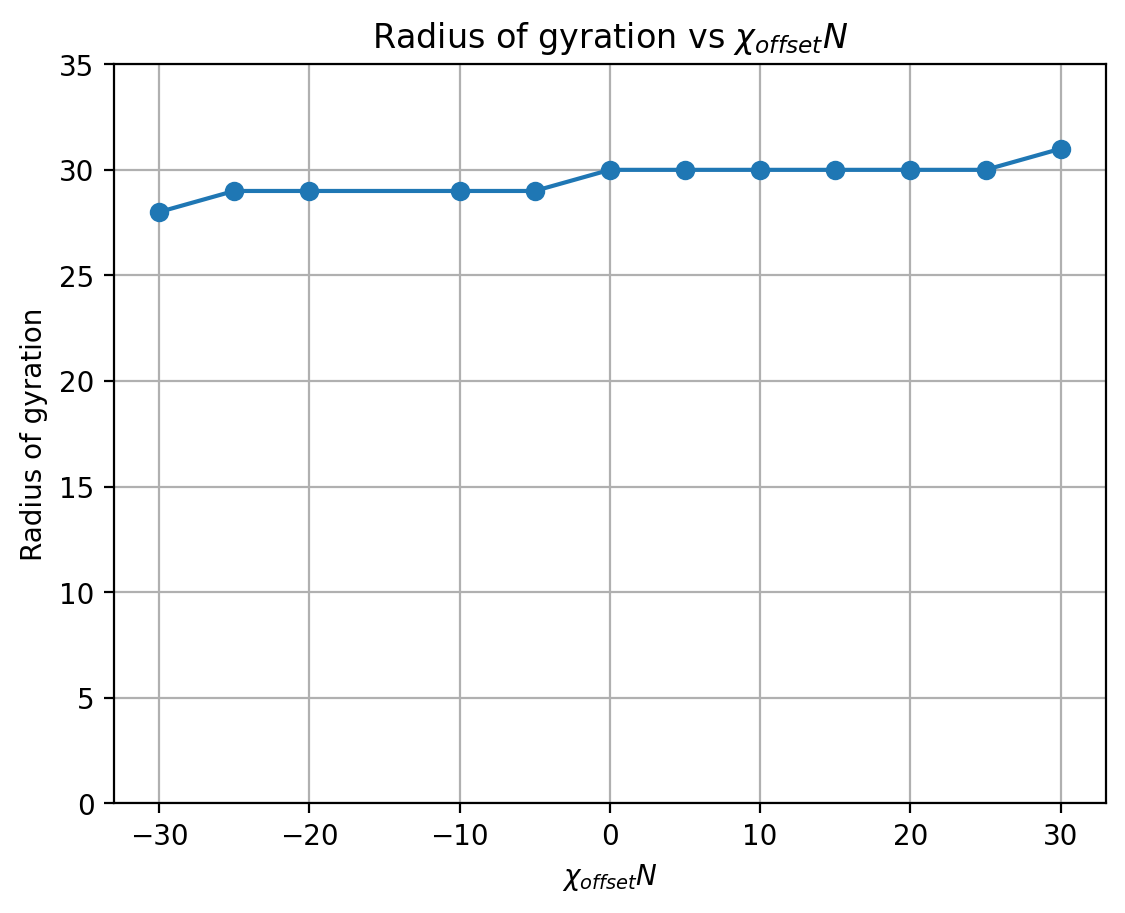

In [33]:
plt.figure(dpi = 200)
plt.plot(offsets, rog_list, marker="o")
plt.title(r"Radius of gyration vs $\chi_{offset}N$")
plt.xlabel(r"$\chi_{offset}N$")
plt.ylabel(r"Radius of gyration")
plt.grid()
plt.ylim(bottom=0)
plt.ylim(top=35)